In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Dataset.csv")

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [4]:
df.shape

(17379, 17)

#### Dataset Structure and Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17379 non-null  str  
 3   yr          17379 non-null  str  
 4   mnth        17379 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17379 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17379 non-null  str  
 9   weathersit  17379 non-null  str  
 10  temp        17379 non-null  str  
 11  atemp       17379 non-null  str  
 12  hum         17379 non-null  str  
 13  windspeed   17379 non-null  str  
 14  casual      17379 non-null  str  
 15  registered  17379 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 3.3 MB


#### Statistical Summary of Numerical Features

In [6]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


####  Handling Invalid Values by Replacing with NaN

In [7]:
import numpy as np

for col in df.columns:
    df[col] = df[col].replace('?', np.nan)

#### Convert Numerical Columns to Numeric Data Type

In [8]:
cols = ['mnth', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

for col in cols:
    df[col] = pd.to_numeric(df[col])

#### Missing Value Analysis

In [9]:
df.isnull().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

#### Handling Missing Values

In [10]:
# For numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64'])
df[num_cols.columns] = num_cols.fillna(num_cols.median())

# For Categorical Columns
cat_cols = df.select_dtypes(include=['string', 'object'])
df[cat_cols.columns] = cat_cols.fillna(cat_cols.mode().iloc[0])

#### Checking Missing Values After Handling

In [11]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Duplicate Value Analysis

In [12]:
df.duplicated().sum()

np.int64(0)

###  Targeted Variable Analysis

#### Statistical Summary of Target Variable

In [13]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

#### Skewness Analysis of Target Variable

In [14]:
df['cnt'].skew()

np.float64(1.2774116037490573)

#### Target Variable Distribution Analysis

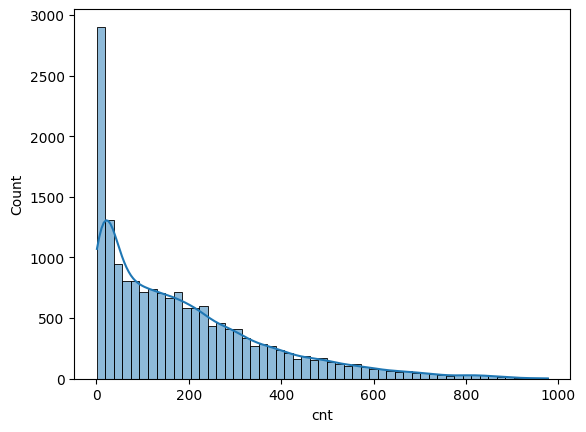

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(x=df['cnt'], kde=True)
plt.show()

### Univariate Analysis

#### Numerical Feature Distribution

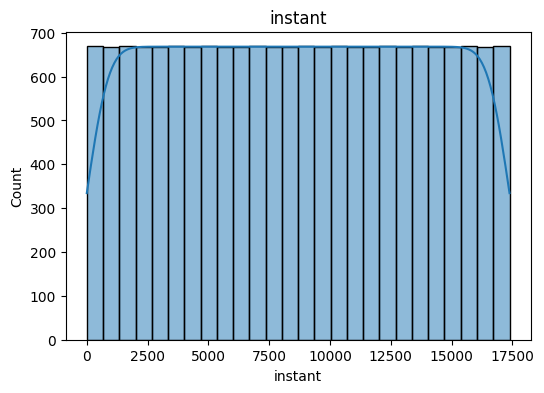

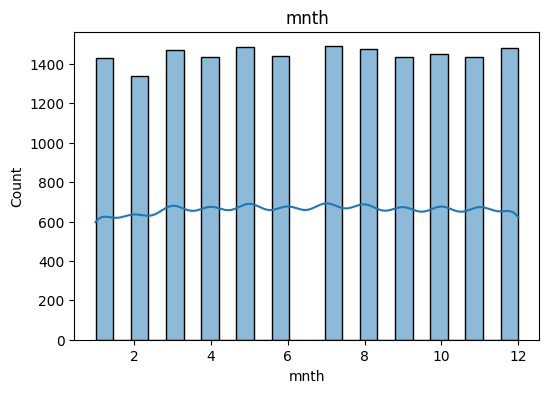

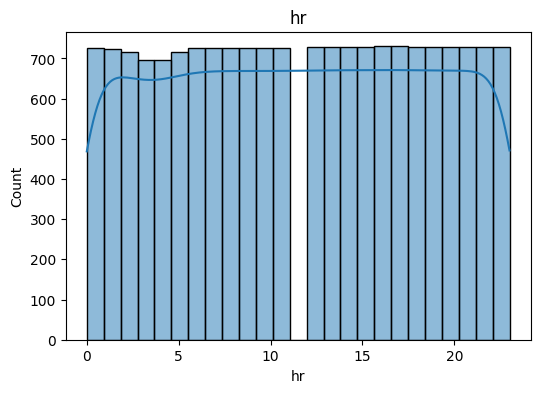

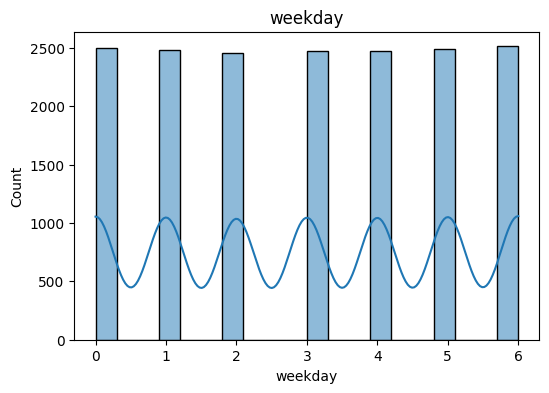

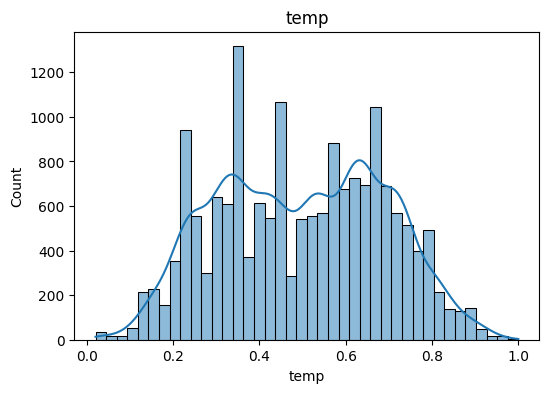

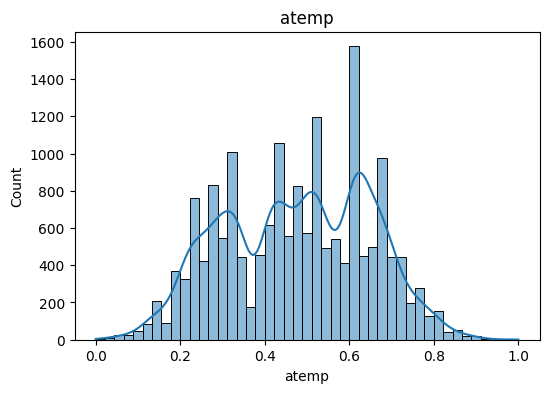

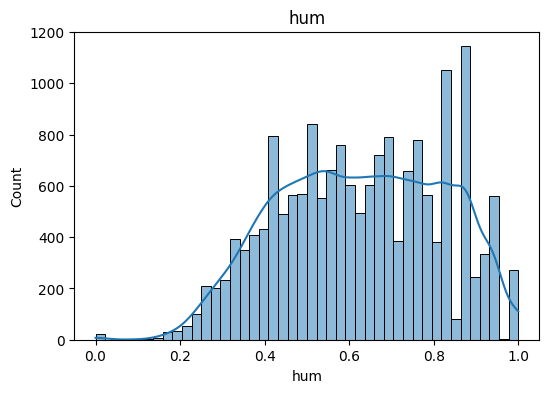

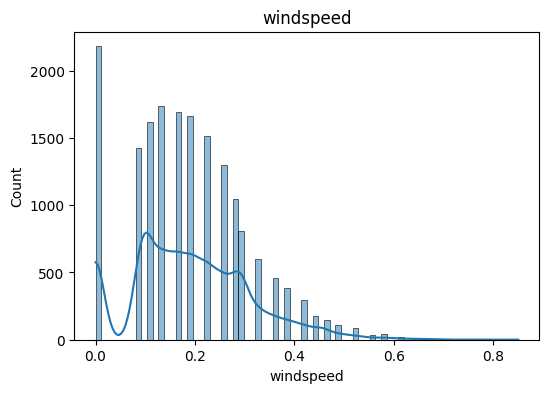

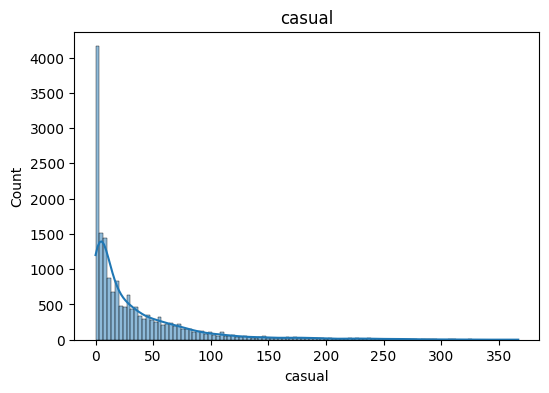

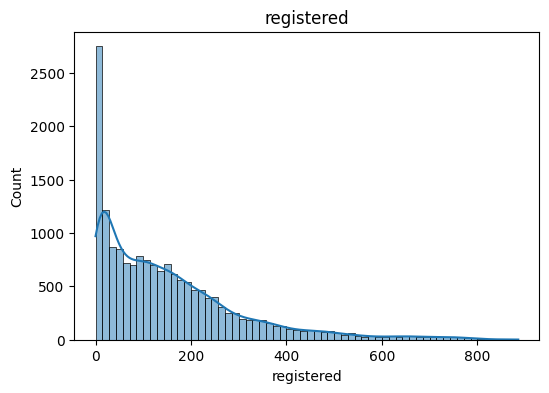

In [16]:
cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('cnt')

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

#### Categorical Feature Distribution

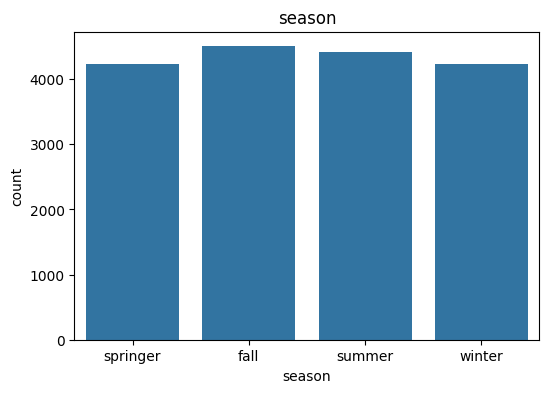

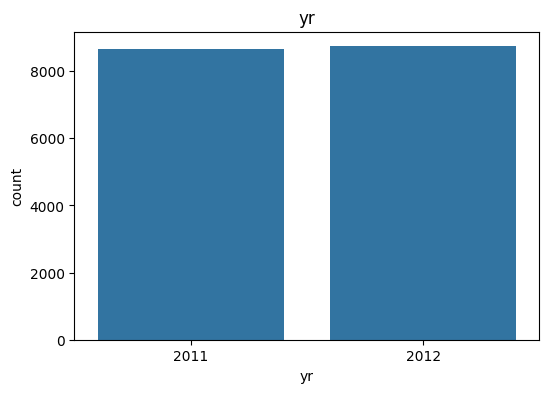

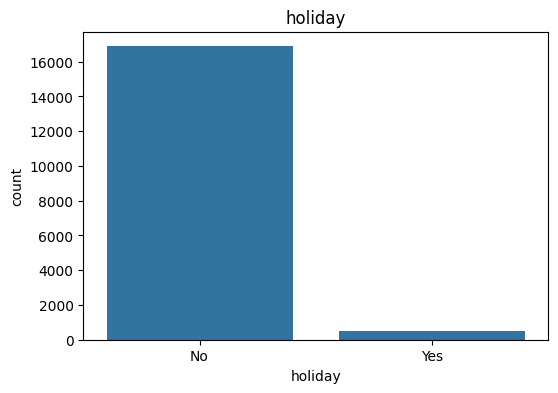

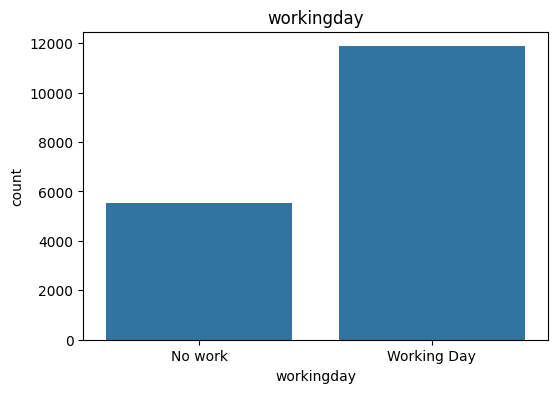

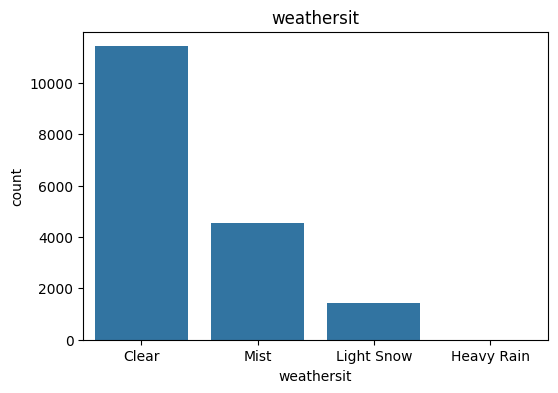

In [17]:
cols = df.select_dtypes(include=['string', 'object']).columns.drop('dteday')

for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

### Bivariate Analysis

#### Time Series Analysis of Bike Rental Demand

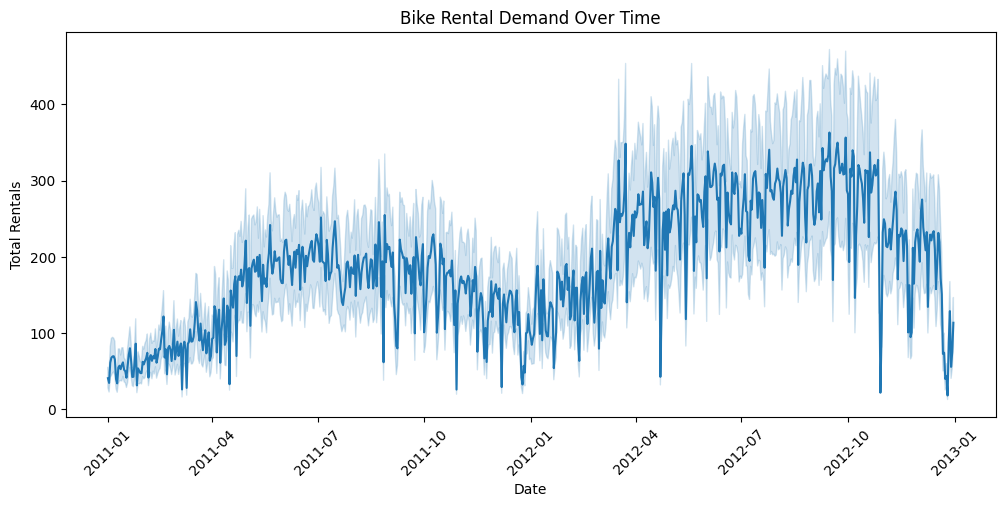

In [18]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)

plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='dteday', y='cnt')
plt.title('Bike Rental Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.xticks(rotation=45)
plt.show()

#### Correlation of Numerical Features with Target Variable

In [19]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.972148
casual        0.694570
temp          0.404482
atemp         0.400890
hr            0.394071
instant       0.278379
mnth          0.120658
windspeed     0.093320
weekday       0.026900
hum          -0.322823
Name: cnt, dtype: float64

#### Relationship Between Numerical Features and Target Variable

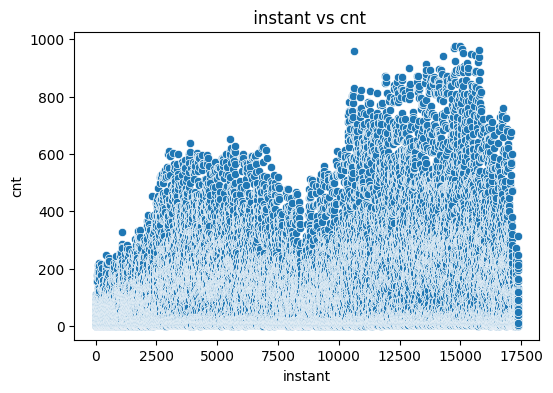

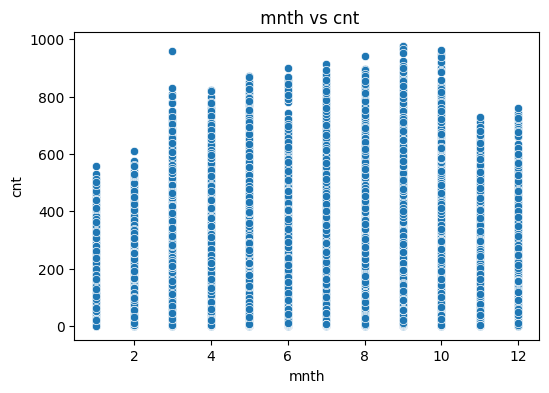

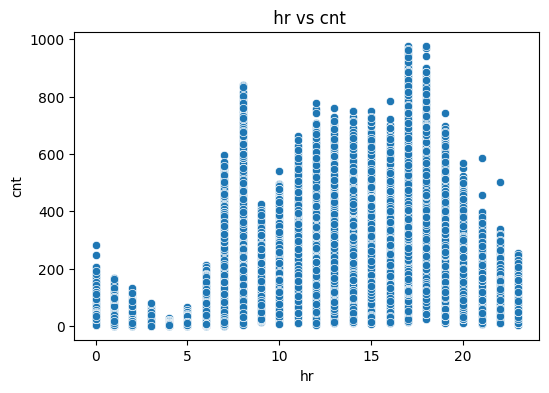

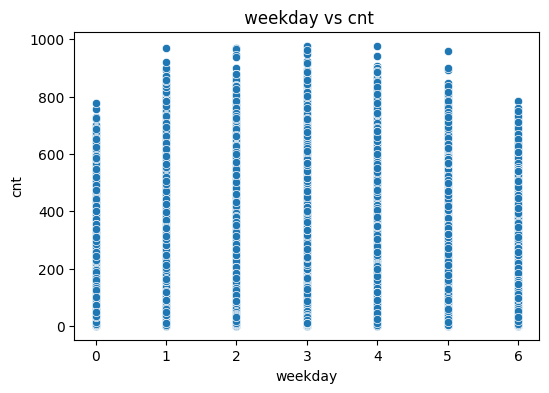

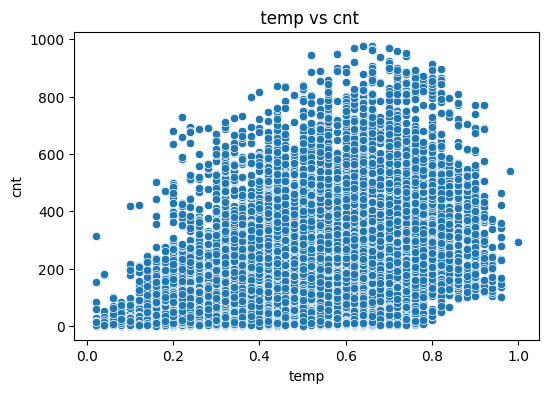

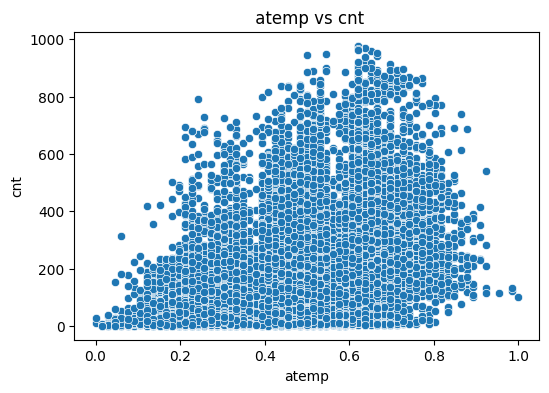

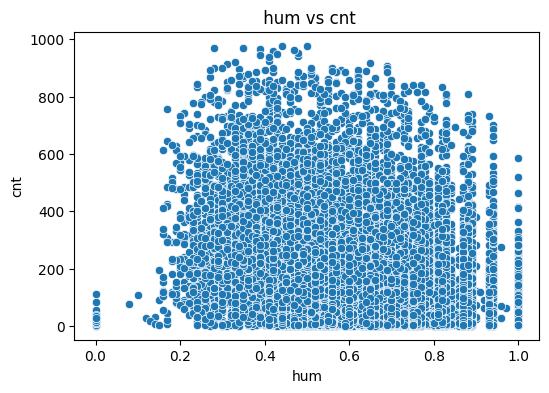

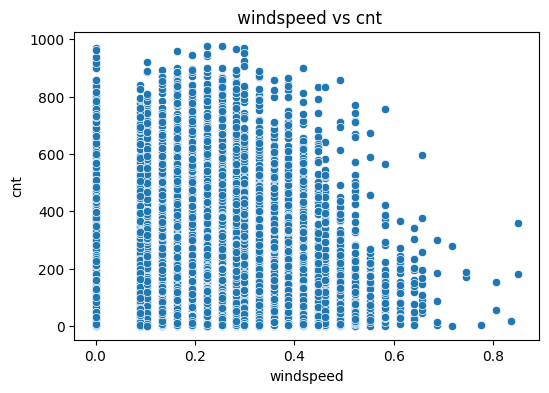

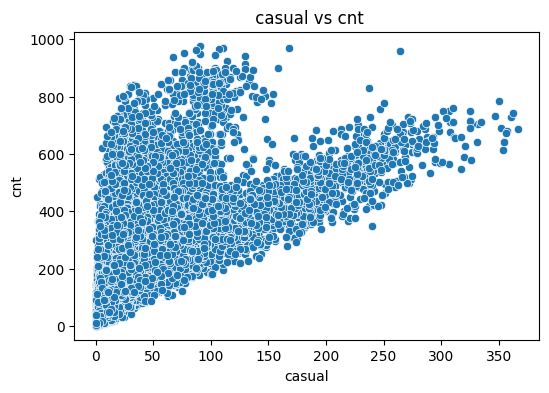

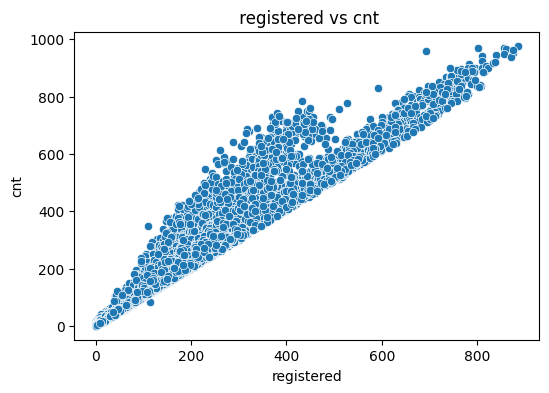

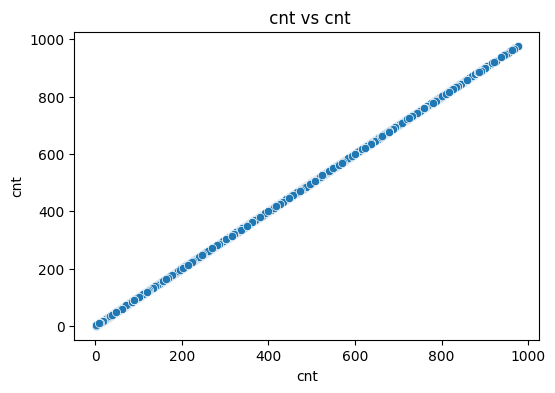

In [20]:
cols = df.select_dtypes(include=['int64', 'float64'])

for col in cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['cnt'])
    plt.title(f" {col} vs cnt")
    plt.show()

#### Correlation Heatmap of Numerical Features

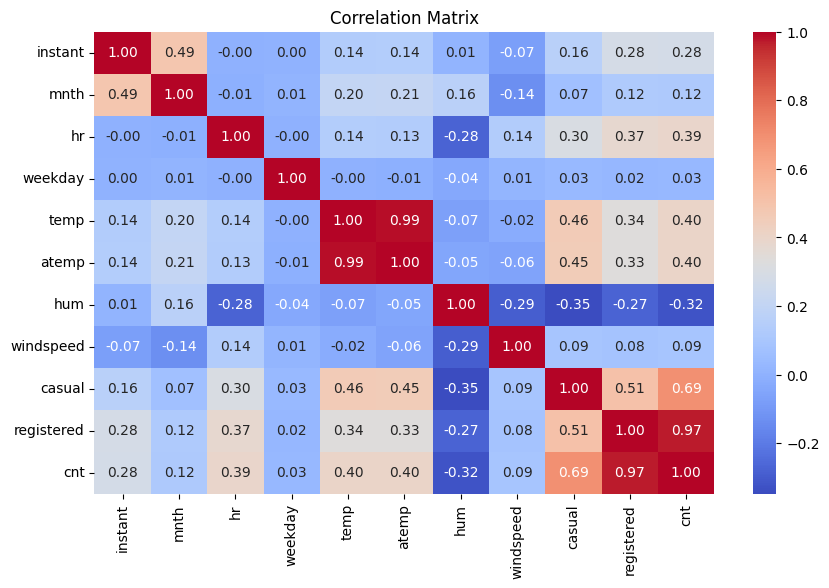

In [21]:
cols = ['instant', 'mnth', 'hr', 'weekday', 'temp', 'atemp', 'hum',
        'windspeed', 'casual', 'registered', 'cnt']

plt.figure(figsize=(10,6))

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Relationship Between Categorical Features and Target Variable

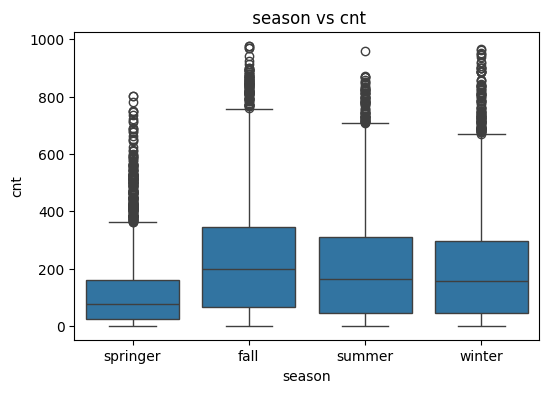

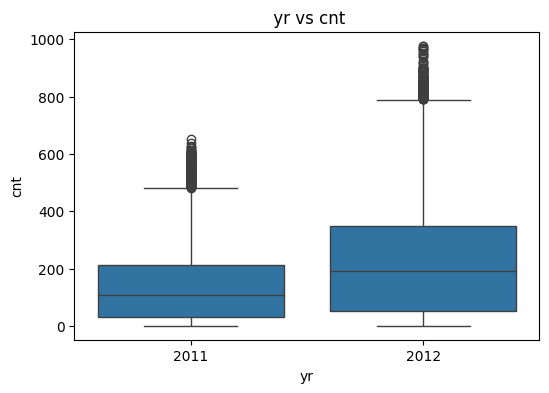

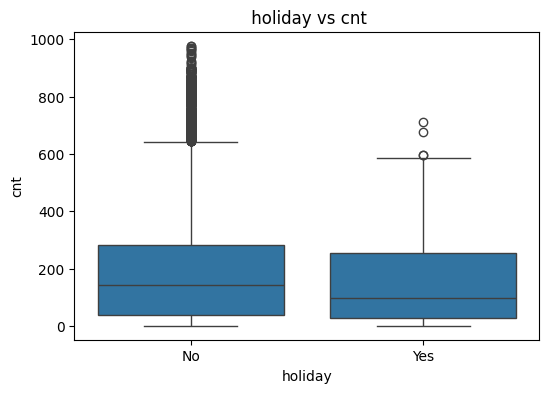

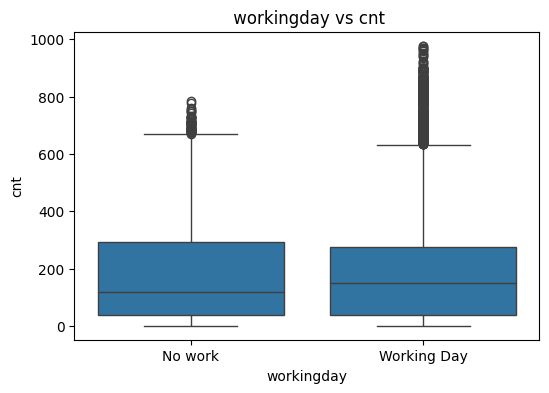

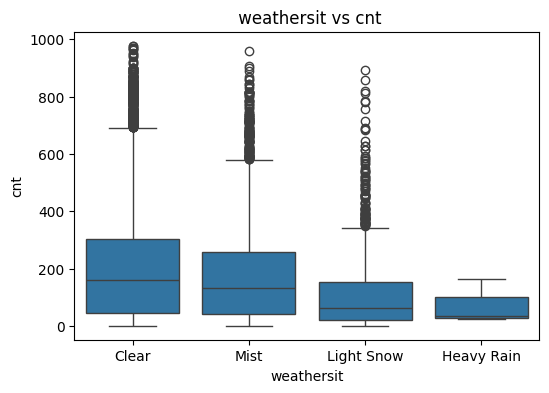

In [22]:
cat_cols = df.select_dtypes(include=['string', 'object'])

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df['cnt'])
    plt.title(f" {col} vs cnt")
    plt.show()

#### Outlier Detection Using Boxplots

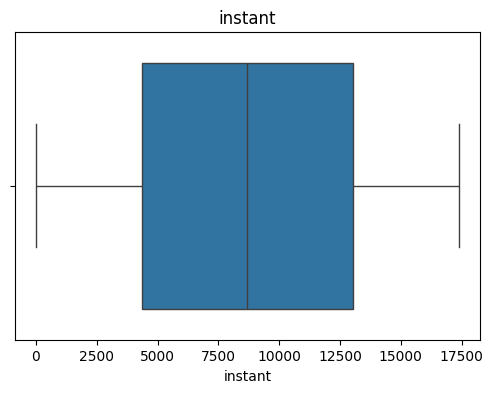

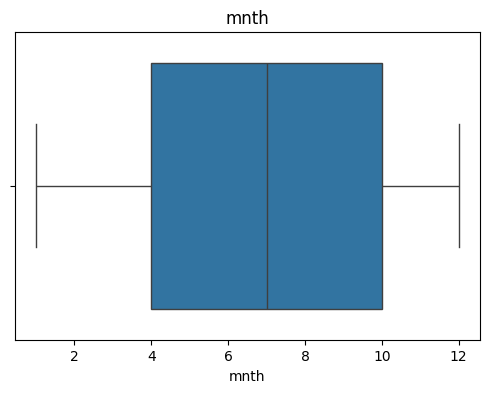

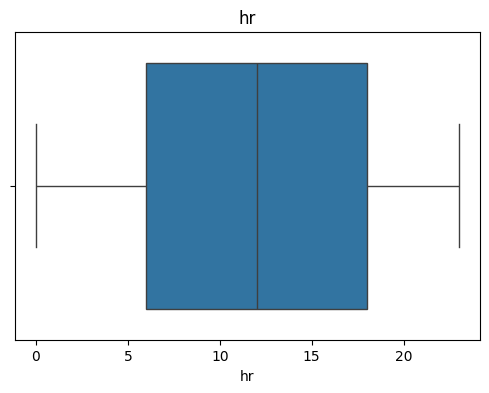

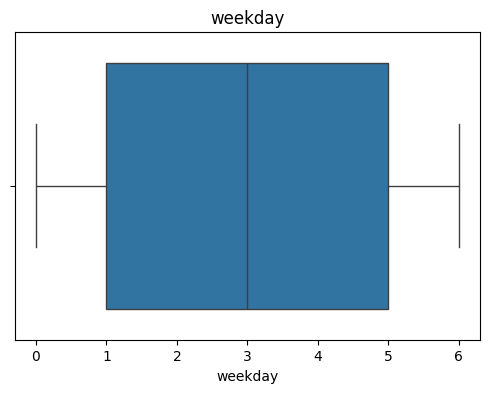

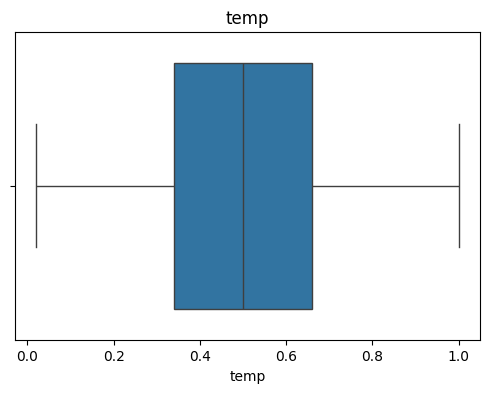

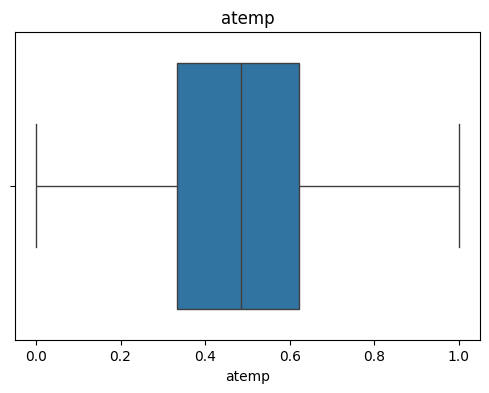

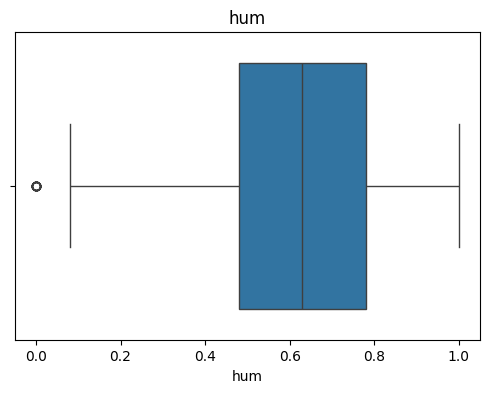

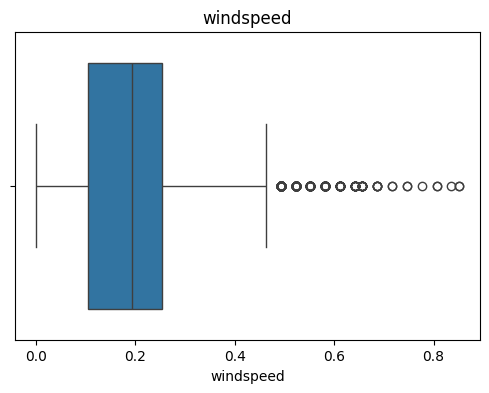

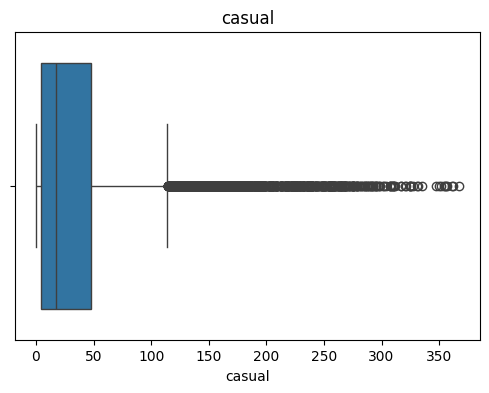

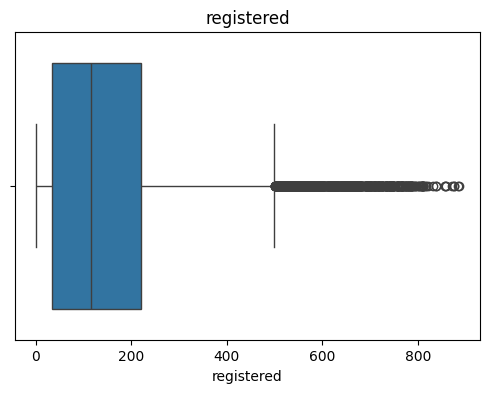

In [23]:
cat_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('cnt')

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Handling Outliers Using IQR Capping

In [24]:
cols = ['registered', 'casual', 'windspeed', 'hum']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

#### Verifying Outliers After Treatment

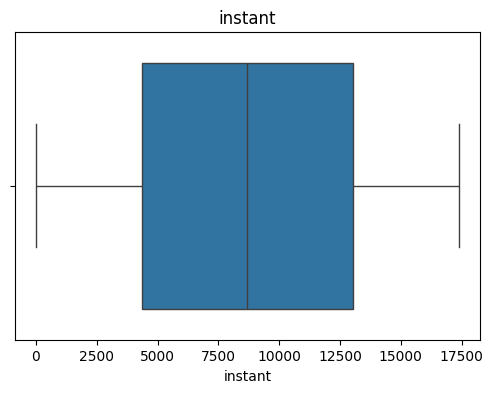

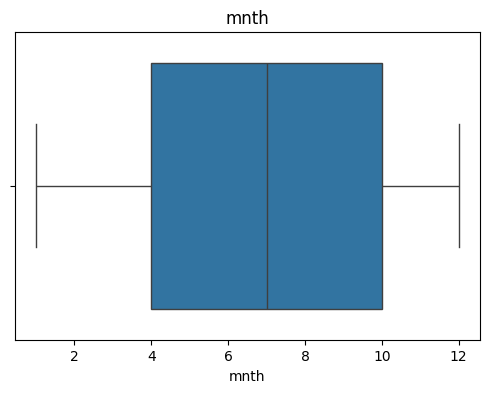

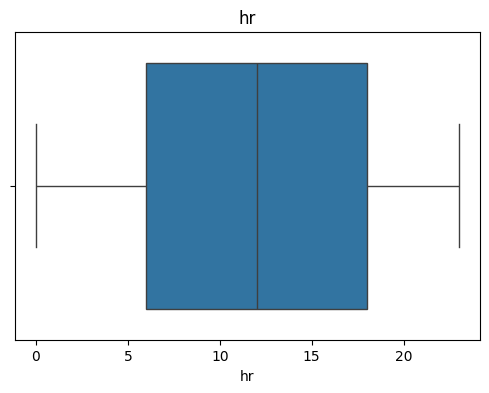

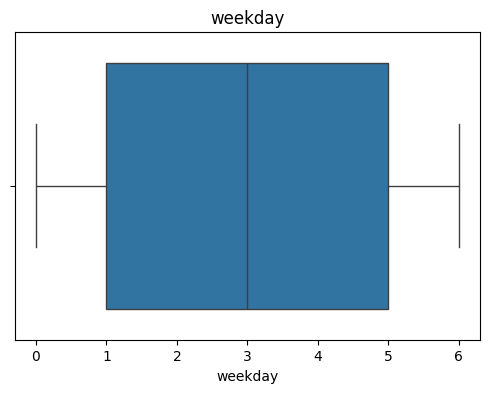

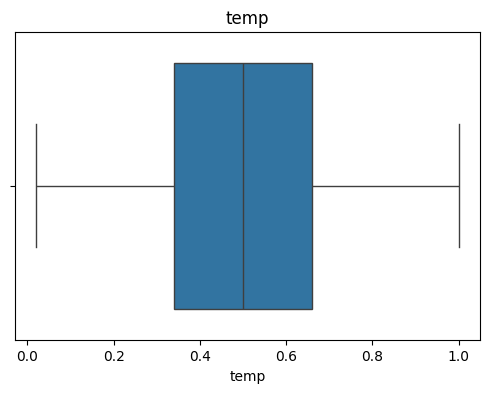

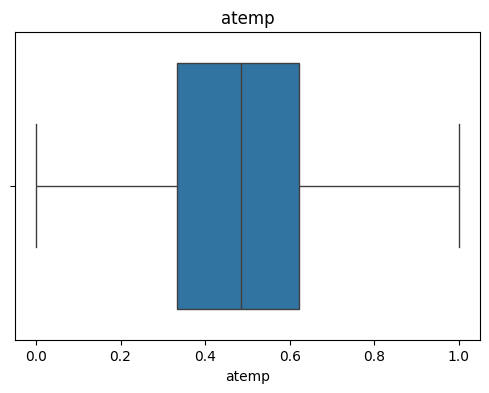

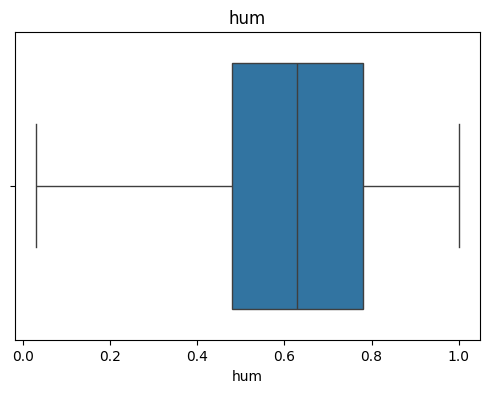

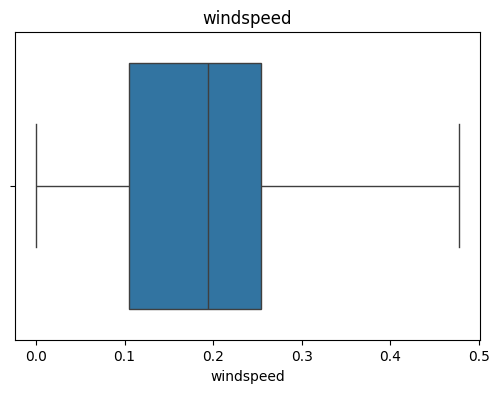

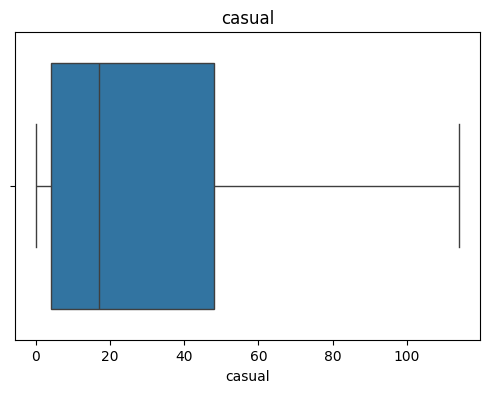

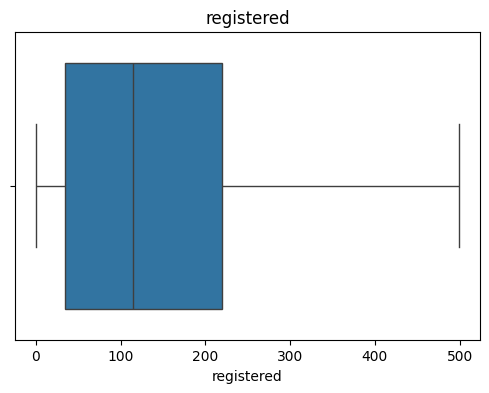

In [25]:
cat_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('cnt')

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Removing Unnecessary Feature

In [26]:
df = df.drop('dteday', axis=1)

#### Removing Data Leakage Features

In [27]:
df = df.drop(['casual', 'registered'], axis=1)

#### Removing Identifier Column

In [28]:
df = df.drop('instant', axis=1)

#### Creating Rush Hour Feature

In [29]:
df['rush_hour'] = df['hr'].apply(
    lambda x: 'Rush Hour' if x in [7, 8, 9, 17, 18, 19] else 'Non Rush Hour'
)

#### Separating Features and Target Variable

In [30]:
X = df.drop('cnt', axis=1)

y = df['cnt']

#### One-Hot Encoding of Categorical Features

In [31]:
X = pd.get_dummies(
    X,
    columns=['season', 'yr', 'holiday', 'workingday', 'weathersit', 'rush_hour', 'mnth'],
    drop_first=True,
    dtype=int
)

#### Splitting the Dataset into Training and Testing Sets

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

#### Feature Scaling Using StandardScaler

In [33]:
from sklearn.preprocessing import StandardScaler

cols = ['hr', 'weekday', 'temp', 'atemp', 'hum', 'windspeed']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])

### Linear Regression

#### Training the Linear Regression Model

In [34]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Making Predictions on the Test Set

In [35]:
y_pred_lr = lr_model.predict(X_test_scaled)

#### Evaluating Linear Regression Model Performance

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2_Score:", r2_lr)

MAE: 86.16624865473912
MSE: 13110.286314610885
RMSE: 114.50015857897702
R2_Score: 0.5859745456861672


### Decision Tree

#### Training the Decision Tree Regressor

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

#### Making Predictions with Decision Tree Regressor

In [38]:
y_pred_dt = dt_model.predict(X_test)

#### Evaluating Decision Tree Regressor Performance

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2_Score:", r2_dt)

MAE: 34.10097813578826
MSE: 3373.8022151898736
RMSE: 58.08444038802366
R2_Score: 0.893454653743734


### Random Forest

#### Training the Random Forest Regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Making Predictions with Random Forest Regressor

In [41]:
y_pred_rf = rf_model.predict(X_test)

#### Evaluating Random Forest Regressor Performance

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2_Score:", r2_rf)

MAE: 24.505267309167625
MSE: 1694.6802175845082
RMSE: 41.166493870434344
R2_Score: 0.9464816610282462


### Gradient Boosting

#### Training the Gradient Boosting Regressor

In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

#### Making Predictions with Gradient Boosting Regressor

In [44]:
y_pred_gb = gb_model.predict(X_test)

#### Evaluating Gradient Boosting Regressor Performance

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2_Score:", r2_gb)

MAE: 45.230972684318836
MSE: 4344.155764798959
RMSE: 65.9102098676598
R2_Score: 0.8628106952838637


### XGBoost

#### Training the XGBoost Regressor

In [46]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

#### Making Predictions with XGBoost Regressor

In [47]:
y_pred_xgb = xgb_model.predict(X_test)

#### Evaluating XGBoost Regressor Performance

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2_Score:", r2_xgb)

MAE: 24.147417068481445
MSE: 1543.5445556640625
RMSE: 39.287969604753854
R2_Score: 0.9512545466423035


### LightGBM

#### Training the LightGBM Regressor

In [49]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(random_state=42,
                           verbose=-1)
lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Making Predictions with LightGBM Regressor

In [50]:
y_pred_lgbm = lgbm_model.predict(X_test)

#### Evaluating LightGBM Regressor Performance

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("MAE:", mae_lgbm)
print("MSE:", mse_lgbm)
print("RMSE:", rmse_lgbm)
print("R2_Score:", r2_lgbm)

MAE: 25.326455257802696
MSE: 1634.4685580573785
RMSE: 40.42856116729086
R2_Score: 0.9483831572345439


### CatBoost

#### Training the CatBoost Regressor

In [52]:
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(random_state=42,
                    verbose=0)
cb_model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

#### Making Predictions with CatBoost Regressor

In [53]:
y_pred_cb = cb_model.predict(X_test)

#### Evaluating CatBoost Regressor Performance

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_cb = mean_absolute_error(y_test, y_pred_cb)
mse_cb = mean_squared_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mse_cb)
r2_cb = r2_score(y_test, y_pred_cb)

print("MAE:", mae_cb)
print("MSE:", mse_cb)
print("RMSE:", rmse_cb)
print("R2_Score:", r2_cb)

MAE: 23.894557387232283
MSE: 1473.8083446053677
RMSE: 38.39021157281329
R2_Score: 0.9534568387902621


### K-Nearest Neighbors (KNN)

#### Training the KNN Regressor

In [55]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Making Predictions with KNN Regressor

In [56]:
y_pred_knn = knn_model.predict(X_test_scaled)

#### Evaluating KNN Regressor Performance

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2_Score:", r2_knn)

MAE: 53.27376294591484
MSE: 6164.73169159954
RMSE: 78.51580536172025
R2_Score: 0.8053165447277162


### Support Vector Machine (SVM)

#### Training the Support Vector Regressor

In [58]:
from sklearn.svm import SVR

svm_model = SVR()
svm_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### Making Predictions with Support Vector Regressor (SVR)

In [59]:
y_pred_svm = svm_model.predict(X_test_scaled)

#### Evaluating Support Vector Regressor (SVR) Performance

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("RMSE:", rmse_svm)
print("R2_Score:", r2_svm)

MAE: 76.91817167534775
MSE: 14078.692243533662
RMSE: 118.65366510788304
R2_Score: 0.5553920934756748


#### Model Performance Comparison

In [61]:
comparison = pd.DataFrame ({
    "Model": [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'KNN Regressor',
        'SVM Regressor'
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_xgb,
        mae_lgbm,
        mae_cb,
        mae_knn,
        mae_svm
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gb,
        mse_xgb,
        mse_lgbm,
        mse_cb,
        mse_knn,
        mse_svm
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb,
        rmse_xgb,
        rmse_lgbm,
        rmse_cb,
        rmse_knn,
        rmse_svm
    ],
    "R2_Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_xgb,
        r2_lgbm,
        r2_cb,
        r2_knn,
        r2_svm
    ]
})

comparison = comparison.sort_values(by='R2_Score', ascending=False).round(4)
comparison

,Model,MAE,MSE,RMSE,R2_Score
6,CatBoost,23.8946,1473.8083,38.3902,0.9535
4,XGBoost,24.1474,1543.5446,39.2880,0.9513
5,LightGBM,25.3265,1634.4686,40.4286,0.9484
2,Random Forest,24.5053,1694.6802,41.1665,0.9465
1,Decision Tree,34.1010,3373.8022,58.0844,0.8935
3,Gradient Boosting,45.2310,4344.1558,65.9102,0.8628
7,KNN Regressor,53.2738,6164.7317,78.5158,0.8053
0,Linear Regression,86.1662,13110.2863,114.5002,0.5860
8,SVM Regressor,76.9182,14078.6922,118.6537,0.5554


#### Hyperparameter Tuning of CatBoost Regressor Using RandomizedSearchCV

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

param_dist = {
    'iterations': [100, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 5, 6, 7, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1.0]
}

random_search_cb = RandomizedSearchCV (
    estimator=cb_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search_cb.fit(X_train, y_train)

print("Best Params:", random_search_cb.best_params_)
print("Best Score:", random_search_cb.best_score_)

Best Params: {'subsample': 1.0, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 1000, 'depth': 8, 'colsample_bylevel': 1.0}
Best Score: 0.9574446796131028


#### Training the Tuned CatBoost Regressor

In [65]:
cb_tuned = CatBoostRegressor(
    subsample=1.0,
    learning_rate=0.1,
    l2_leaf_reg=5,
    iterations=1000,
    depth=8,
    colsample_bylevel=1.0,
    random_state=42,
    verbose=0
)

cb_tuned.fit(X_train, y_train)

CatBoostRegressor(colsample_bylevel=1.0, depth=8, iterations=1000, l2_leaf_reg=5, learning_rate=0.1, loss_function='RMSE', random_state=42, subsample=1.0, verbose=0)

#### Making Predictions with Tuned CatBoost Regressor

In [66]:
y_pred_cb_tuned = cb_tuned.predict(X_test)

#### Evaluating Tuned CatBoost Regressor Performance

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_cb_tuned = mean_absolute_error(y_test, y_pred_cb_tuned)
mse_cb_tuned = mean_squared_error(y_test, y_pred_cb_tuned)
rmse_cb_tuned = np.sqrt(mse_cb_tuned)
r2_cb_tuned = r2_score(y_test, y_pred_cb_tuned)

print("MAE:", mae_cb_tuned)
print("MSE:", mse_cb_tuned)
print("RMSE:", rmse_cb_tuned)
print("R2_Score:", r2_cb_tuned)

MAE: 21.99119295270827
MSE: 1280.1438660331519
RMSE: 35.77909817244073
R2_Score: 0.9595728016152657


#### Hyperparameter Tuning of XGBoost Regressor Using RandomizedSearchCV

In [69]:
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBRegressor(random_state=42,
                        objective='reg:squarederror')

param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print("Best Params:", random_search_xgb.best_params_)
print("Best Score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'subsample': 1.0, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best Score: 0.9538472414016723


#### Training the Tuned XGBoost Regressor

In [70]:
xgb_tuned = XGBRegressor(
    subsample=1.0,
    n_estimators=700,
    min_child_weight=1,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.2,
    colsample_bytree=1.0,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Making Predictions with Tuned XGBoost Regressor

In [71]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

#### Evaluating Tuned XGBoost Regressor Performance

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("MAE:", mae_xgb_tuned)
print("MSE:", mse_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R2_Score:", r2_xgb_tuned)

MAE: 22.542539596557617
MSE: 1378.56298828125
RMSE: 37.129004676684374
R2_Score: 0.9564647078514099


#### Hyperparameter Tuning of LightGBM Regressor Using RandomizedSearchCV

In [73]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_model = LGBMRegressor(random_state=42,
                           verbose=-1)

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, -1],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [10, 20, 30, 50]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

print("Best Params:", random_search_lgbm.best_params_)
print("Best Score:", random_search_lgbm.best_score_)

Best Params: {'num_leaves': 50, 'n_estimators': 700, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05}
Best Score: 0.9538983974875863


#### Training the Tuned LightGBM Regressor

In [76]:
lgbm_tuned = LGBMRegressor(
    num_leaves=50,
    n_estimators=700,
    min_child_samples=20,
    max_depth=-1,
    learning_rate=0.05,
    verbose=-1,
    random_state=42
)

lgbm_tuned.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.05
,n_estimators,700
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Making Predictions with Tuned LightGBM Regressor

In [79]:
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

#### Evaluating Tuned LightGBM Regressor Performance

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lgbm_tuned = mean_absolute_error(y_test, y_pred_lgbm_tuned)
mse_lgbm_tuned = mean_squared_error(y_test, y_pred_lgbm_tuned)
rmse_lgbm_tuned = np.sqrt(mse_lgbm_tuned)
r2_lgbm_tuned = r2_score(y_test, y_pred_lgbm_tuned)

print("MAE:", mae_lgbm_tuned)
print("MSE:", mse_lgbm_tuned)
print("RMSE:", rmse_lgbm_tuned)
print("R2_Score:", r2_lgbm_tuned)

MAE: 22.587053663284745
MSE: 1381.9521594516584
RMSE: 37.17461713927473
R2_Score: 0.95635767542168


#### Hyperparameter Tuning of Random Forest Regressor Using RandomizedSearchCV

In [88]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'max_depth': [None, 10, 15, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter = 40,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best Params:", random_search_rf.best_params_)
print("Best Score:", random_search_rf.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None, 'bootstrap': True}
Best Score: 0.9425051288577577


#### Training the Tuned Random Forest Regressor

In [91]:
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_depth=None,
    bootstrap=True,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

#### Making Predictions with Tuned Random Forest Regressor

In [93]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

#### Evaluating Tuned Random Forest Regressor Performance

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("MAE:", mae_rf_tuned)
print("MSE:", mse_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2_Score:", r2_rf_tuned)

MAE: 24.481296669223887
MSE: 1689.1658580059986
RMSE: 41.099462989265426
R2_Score: 0.9466558056025868


#### Final Performance Comparison: Original vs Tuned Models

In [99]:
final_comparison = pd.DataFrame ({
    "Model": [
        'CatBoost(Original)',
        'CatBoost(Tuned)',
        'XGBoost(Original)',
        'XGBoost(Tuned)',
        'LightGBM(Original)',
        'LightGBM(Tuned)',
        'Random Forest(Original)',
        'Random Forest(Tuned)'
    ],
    "MAE": [
        mae_cb,
        mae_cb_tuned,
        mae_xgb,
        mae_xgb_tuned,
        mae_lgbm,
        mae_lgbm_tuned,
        mae_rf,
        mae_rf_tuned
    ],
    "MSE": [
        mse_cb,
        mse_cb_tuned,
        mse_xgb,
        mse_xgb_tuned,
        mse_lgbm,
        mse_lgbm_tuned,
        mse_rf,
        mse_rf_tuned
    ],
    "RMSE": [
        rmse_cb,
        rmse_cb_tuned,
        rmse_xgb,
        rmse_xgb_tuned,
        rmse_lgbm,
        rmse_lgbm_tuned,
        rmse_rf,
        rmse_rf_tuned
    ],
    "R2_Score": [
        r2_cb,
        r2_cb_tuned,
        r2_xgb,
        r2_xgb_tuned,
        r2_lgbm,
        r2_lgbm_tuned,
        r2_rf,
        r2_rf_tuned
    ]
})

final_comparison = final_comparison.sort_values(by='R2_Score', ascending=False).round(4)
final_comparison

,Model,MAE,MSE,RMSE,R2_Score
1,CatBoost(Tuned),21.9912,1280.1439,35.7791,0.9596
3,XGBoost(Tuned),22.5425,1378.5630,37.1290,0.9565
5,LightGBM(Tuned),22.5871,1381.9522,37.1746,0.9564
0,CatBoost(Original),23.8946,1473.8083,38.3902,0.9535
2,XGBoost(Original),24.1474,1543.5446,39.2880,0.9513
4,LightGBM(Original),25.3265,1634.4686,40.4286,0.9484
7,Random Forest(Tuned),24.4813,1689.1659,41.0995,0.9467
6,Random Forest(Original),24.5053,1694.6802,41.1665,0.9465


### Final Selected Model Performance

In [101]:
final_model = pd.DataFrame ({
    "Model": [
        'CatBoost(Tuned)'
    ],
    "MAE": [
        mae_cb_tuned
    ],
    "MSE": [
        mse_cb_tuned
    ],
    "RMSE": [
        rmse_cb_tuned
    ],
    "R2_Score": [
        r2_cb_tuned
    ]
})

final_model

,Model,MAE,MSE,RMSE,R2_Score
0,CatBoost(Tuned),21.991193,1280.143866,35.779098,0.959573


#### Training and Testing Performance Evaluation

In [105]:
print("Train Score:", cb_tuned.score(X_train, y_train))
print("Test Score:", cb_tuned.score(X_test, y_test))

Train Score: 0.985501817442126
Test Score: 0.9595728016152657


###### The Tuned CatBoost Regressor achieved excellent predictive performance on the dataset. The model obtained a **Training R² Score of 0.9855** and a **Testing R² Score of 0.9596**, resulting in a difference of only **2.6%**. This small gap indicates that the model generalizes well to unseen data and does not exhibit significant overfitting. Overall, the Tuned CatBoost Regressor can be considered a reliable and robust model for predicting bike rental demand.


#### Residual Distribution Analysis

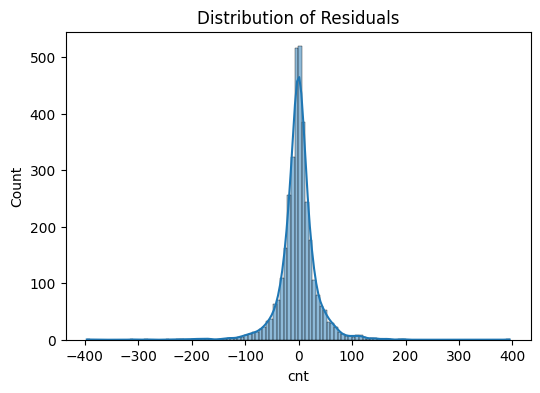

In [108]:
residuals = y_test - y_pred_cb_tuned

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

#### Residual Plot (Predicted Values vs Residuals)

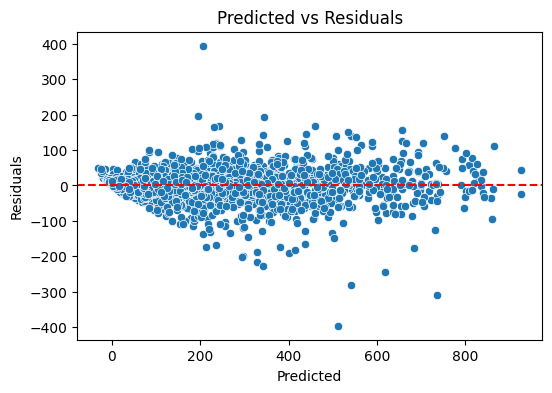

In [111]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=y_pred_cb_tuned, y=residuals)
plt.axhline(y=0, linestyle='--', color='red')
plt.title("Predicted vs Residuals")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

#### Actual vs Predicted Values

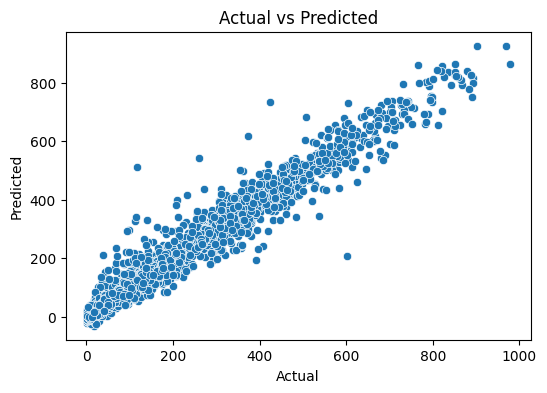

In [114]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=y_test, y=y_pred_cb_tuned)
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

#### Top 10 Most Important Features

In [118]:
feature_importance = pd.DataFrame ({
    'Feature': X.columns,
    'Importance': cb_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(10)
feature_importance

,Feature,Importance
0,hr,38.494725
15,rush_hour_Rush Hour,16.078717
11,workingday_Working Day,13.915570
9,yr_2012,9.498046
3,atemp,5.453320
2,temp,4.443524
4,hum,2.542013
6,season_springer,2.469572
1,weekday,1.728043
13,weathersit_Light Snow,1.665590


#### Top 10 Most Important Features Visualization

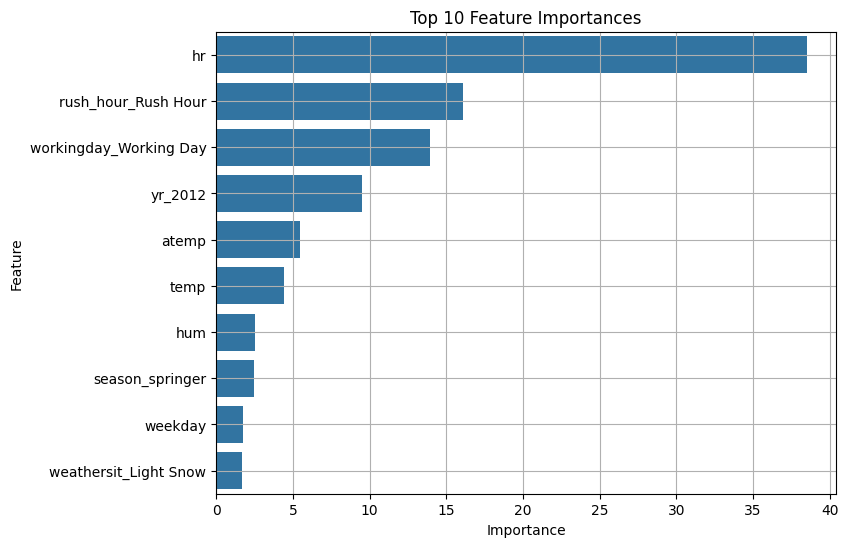

In [125]:
top_10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(data=top_10, x='Importance', y='Feature')
plt.title("Top 10 Feature Importances")
plt.grid()
plt.show()

#### SHAP Analysis

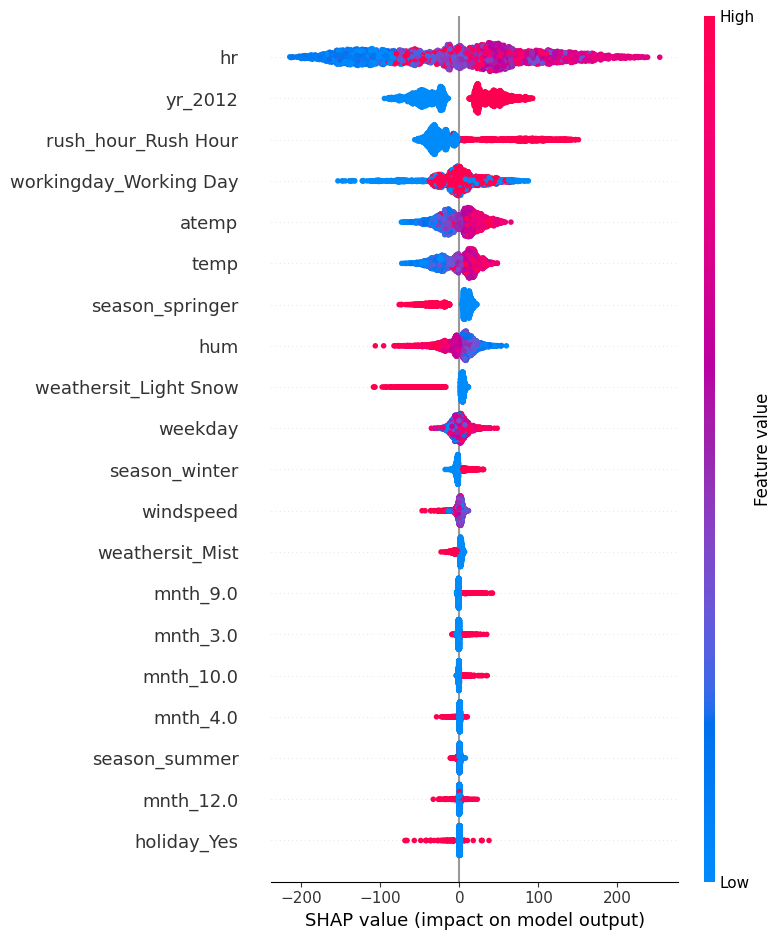

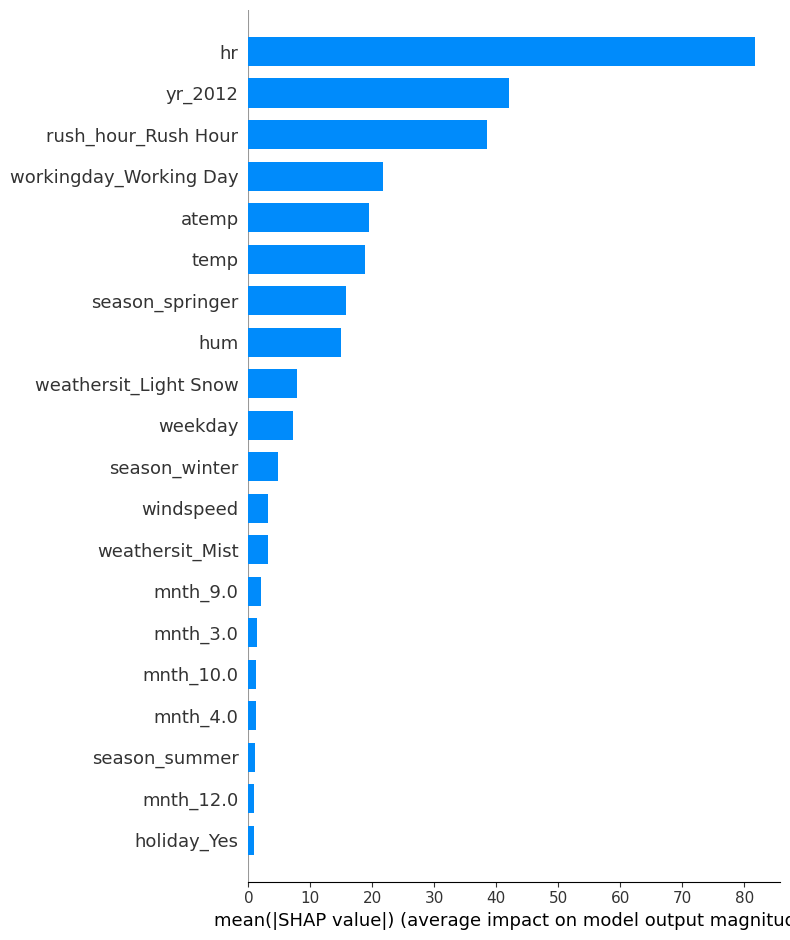

In [133]:
import shap

# Create SHAP Explainer
explainer = shap.TreeExplainer(cb_tuned)

# Calculate SHAP Values
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test)

# SHAP Feature Importance (Bar Plot)
shap.summary_plot(shap_values, X_test, plot_type="bar")

#### Saving the Final Tuned CatBoost Model

In [135]:
import joblib

joblib.dump(cb_tuned, "catboost_final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


#### Saving Feature Columns for Deployment

In [136]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature Columns Saved Successfully")

Feature Columns Saved Successfully
